# 000 — Correct BCHH instrument response

This is the canonical production notebook for the Falcon 9 Fireball analysis.
It:

1. loads the event-epoch StationXML;
2. applies the empirical infraBSU sensitivities to the three DD responses;
3. reads the packaged six-channel raw miniSEED event window, falling back
   to the SDS archive only when that file is absent;
4. removes the complete instrument responses;
5. combines geometry, calibration, processing, and trace statistics;
6. saves raw and corrected miniSEED, metadata-preserving Pickle, StationXML,
   CSV, JSON, and diagnostic-figure products; and
7. optionally registers the event in the flat-file event catalogue.

The waveform and StationXML products now use the same NSLC identifiers
(`DD1`–`DD3` and `DHE`/`DHN`/`DHZ`). No channel-code remapping or Antelope
calibration-table processing is required.

**Channel convention.** The calibrated waveform products use D* channel codes throughout: DD1/DD2/DD3 for infrasound and DHE/DHN/DHZ for seismic. Legacy/manual pick exports may retain historical H* codes; those are mapped explicitly to D* codes in Notebook 04 rather than changing the waveform channel names.


## 1. Imports and configuration

In [1]:
from __future__ import annotations

import copy
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, UTCDateTime, read, read_inventory
from obspy.clients.filesystem.sds import Client
from obspy.core.inventory import Inventory
from obspy.core.util.attribdict import AttribDict
from pyproj import Geod

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config
from modules.kml_utils import read_kml_points

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

In [2]:
READ_START = config.EXPLOSION_TIME - config.PRETRIGGER_WINDOW
READ_END = config.EXPLOSION_TIME + config.POSTTRIGGER_WINDOW

PRESSURE_BASELINE_START = config.EXPLOSION_TIME - 20.0
PRESSURE_BASELINE_END = config.EXPLOSION_TIME - 2.0

INFRASOUND_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
SEISMIC_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
RESPONSE_WATER_LEVEL_DB = 60.0
RAW_BOUNDARY_SHORTFALL_TOLERANCE_S = 0.25

BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

PRESSURE_CHANNELS = ("DD1", "DD2", "DD3")
SEISMIC_CHANNELS = ("DHE", "DHN", "DHZ")
CHANNEL_ORDER = PRESSURE_CHANNELS + SEISMIC_CHANNELS

# Empirical infraBSU calibration in physical units per digital count.
EMPIRICAL_CALIBRATIONS_PA_PER_COUNT = {
    "DD1": 0.1234,
    "DD2": 1.4499,
    "DD3": 0.1000,
}

for required_path, label in (
    (config.STATIONXML_FILE, "StationXML"),
    (config.KML_FILE, "launchpad and camera KML"),
):
    if not required_path.exists():
        raise FileNotFoundError(f"{label} not found: {required_path}")

RAW_MSEED_AVAILABLE = config.RAW_MSEED.is_file()
configured_sds_dir = getattr(config, "SDS_DIR", None)
SDS_AVAILABLE = (
    not RAW_MSEED_AVAILABLE
    and configured_sds_dir is not None
    and Path(configured_sds_dir).is_dir()
)
if not RAW_MSEED_AVAILABLE and not SDS_AVAILABLE:
    raise FileNotFoundError(
        "Raw waveform input not found. Expected primary miniSEED at "
        f"{config.RAW_MSEED}; SDS fallback also unavailable at "
        f"{configured_sds_dir}"
    )
print(
    "Raw waveform source: "
    + (
        str(config.RAW_MSEED)
        if RAW_MSEED_AVAILABLE
        else f"SDS fallback: {configured_sds_dir}"
    )
)

Raw waveform source: SDS fallback: /Volumes/haldata/remastered/SDS_KSC


## 2. Load and calibrate the event-epoch inventory

The active StationXML supplies NSLC identifiers, coordinates, channel
orientations, sample rates, and nominal response shapes. The three DD response
amplitudes are rescaled to the adopted empirical Pa/count calibrations while
retaining their response poles, zeros, and digital stages.

In [3]:
def load_event_inventory(
    stationxml_file: Path,
    *,
    network: str,
    station: str,
    location: str,
    channels: tuple[str, ...],
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> Inventory:
    """Load exactly the active channel epochs required for this event."""
    inventory = read_inventory(str(stationxml_file))
    selected = copy.deepcopy(
        inventory.select(
            network=network,
            station=station,
            location=location,
            starttime=starttime,
            endtime=endtime,
        )
    )

    required = set(channels)
    for net in selected:
        for sta in net:
            sta.channels = [
                channel
                for channel in sta.channels
                if channel.code in required
                and (
                    channel.start_date is None
                    or channel.start_date <= endtime
                )
                and (
                    channel.end_date is None
                    or channel.end_date >= starttime
                )
            ]

    found = {
        channel.code
        for net in selected
        for sta in net
        for channel in sta
    }
    if found != required:
        raise ValueError(
            "StationXML channel mismatch: "
            f"missing={sorted(required - found)}, "
            f"unexpected={sorted(found - required)}"
        )
    return selected


def inventory_channels_to_dataframe(
    inventory: Inventory,
) -> pd.DataFrame:
    """Flatten channel geometry and response sensitivity metadata."""
    rows = []
    for network in inventory:
        for station in network:
            for channel in station:
                sensitivity = getattr(
                    channel.response,
                    "instrument_sensitivity",
                    None,
                )
                rows.append({
                    "seed_id": (
                        f"{network.code}.{station.code}."
                        f"{channel.location_code}.{channel.code}"
                    ),
                    "network": network.code,
                    "station": station.code,
                    "location": channel.location_code,
                    "channel": channel.code,
                    "latitude": float(channel.latitude),
                    "longitude": float(channel.longitude),
                    "elevation_m": float(channel.elevation),
                    "depth_m": float(channel.depth),
                    "azimuth_deg": (
                        None
                        if channel.azimuth is None
                        else float(channel.azimuth)
                    ),
                    "dip_deg": (
                        None if channel.dip is None else float(channel.dip)
                    ),
                    "sample_rate_hz": (
                        None
                        if channel.sample_rate is None
                        else float(channel.sample_rate)
                    ),
                    "sensitivity": (
                        None
                        if sensitivity is None
                        else float(sensitivity.value)
                    ),
                    "sensitivity_frequency_hz": (
                        None
                        if sensitivity is None
                        else float(sensitivity.frequency)
                    ),
                    "input_units": (
                        None
                        if sensitivity is None
                        else str(sensitivity.input_units)
                    ),
                    "output_units": (
                        None
                        if sensitivity is None
                        else str(sensitivity.output_units)
                    ),
                })
    result = pd.DataFrame(rows)
    if result["seed_id"].duplicated().any():
        duplicates = result.loc[
            result["seed_id"].duplicated(keep=False),
            "seed_id",
        ].tolist()
        raise ValueError(f"Duplicate StationXML channel epochs: {duplicates}")
    return result.sort_values("channel").reset_index(drop=True)


def add_source_geometry(
    channel_metadata: pd.DataFrame,
    *,
    kml_file: Path,
    source_name: str = "SLC40",
) -> pd.DataFrame:
    """Add WGS84 source-to-sensor distances and azimuths."""
    points = read_kml_points(kml_file)
    if source_name not in points:
        raise KeyError(
            f"{source_name!r} not found in {kml_file}; "
            f"available={sorted(points)}"
        )

    source = points[source_name]
    result = channel_metadata.copy()
    geod = Geod(ellps="WGS84")
    azimuth, back_azimuth, distance = geod.inv(
        np.full(len(result), float(source["lon"])),
        np.full(len(result), float(source["lat"])),
        result["longitude"].to_numpy(float),
        result["latitude"].to_numpy(float),
    )
    result["source_name"] = source_name
    result["source_latitude"] = float(source["lat"])
    result["source_longitude"] = float(source["lon"])
    result["source_elevation_m"] = source.get("altitude_m")
    result["source_to_sensor_distance_m"] = distance
    result["source_to_sensor_azimuth_deg"] = np.asarray(azimuth) % 360.0
    result["sensor_to_source_back_azimuth_deg"] = (
        np.asarray(back_azimuth) % 360.0
    )
    return result


def single_inventory_channel(
    inventory: Inventory,
    seed_id: str,
    time: UTCDateTime,
):
    """Return exactly one active StationXML Channel for a SEED identifier."""
    network, station, location, channel_code = seed_id.split(".")
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        channel=channel_code,
        time=time,
    )
    channels = [
        channel
        for network in selected
        for station in network
        for channel in station
    ]
    if len(channels) != 1:
        raise ValueError(
            f"Expected one active StationXML channel for {seed_id}; "
            f"found {len(channels)}"
        )
    return channels[0]


def build_empirically_calibrated_inventory(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    calibrations_pa_per_count: dict[str, float],
    time: UTCDateTime,
) -> Inventory:
    """Rescale DD response amplitudes to empirical count/Pa sensitivity."""
    calibrated = copy.deepcopy(inventory)
    for channel_code, pa_per_count in calibrations_pa_per_count.items():
        if pa_per_count <= 0:
            raise ValueError(
                f"{channel_code} calibration must be positive: "
                f"{pa_per_count}"
            )

        seed_id = (
            f"{network}.{station}.{location}.{channel_code}"
        )
        channel = single_inventory_channel(calibrated, seed_id, time)
        response = channel.response
        if response is None or not response.response_stages:
            raise ValueError(f"No usable response for {seed_id}")

        old_sensitivity = float(response.instrument_sensitivity.value)
        new_sensitivity = 1.0 / float(pa_per_count)
        scale_factor = new_sensitivity / old_sensitivity

        first_stage = response.response_stages[0]
        first_stage.stage_gain = (
            float(first_stage.stage_gain) * scale_factor
        )
        response.instrument_sensitivity.value = new_sensitivity
        response.instrument_sensitivity.frequency = 1.0
        response.instrument_sensitivity.input_units = "Pa"
        response.instrument_sensitivity.output_units = "count"
    return calibrated


inventory_event = load_event_inventory(
    config.STATIONXML_FILE,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channels=CHANNEL_ORDER,
    starttime=READ_START,
    endtime=READ_END,
)
channel_metadata_df = add_source_geometry(
    inventory_channels_to_dataframe(inventory_event),
    kml_file=config.KML_FILE,
)
channel_metadata_df["empirical_pa_per_count"] = (
    channel_metadata_df["channel"].map(
        EMPIRICAL_CALIBRATIONS_PA_PER_COUNT
    )
)
channel_metadata_df["empirical_count_per_pa"] = (
    1.0 / channel_metadata_df["empirical_pa_per_count"]
)

inventory_corrected = build_empirically_calibrated_inventory(
    inventory_event,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    calibrations_pa_per_count=EMPIRICAL_CALIBRATIONS_PA_PER_COUNT,
    time=config.EXPLOSION_TIME,
)

inventory_event.write(
    str(config.EVENT_STATIONXML_COPY),
    format="STATIONXML",
    validate=True,
)
inventory_corrected.write(
    str(config.FINAL_INVENTORY_XML),
    format="STATIONXML",
    validate=True,
)
channel_metadata_df.to_csv(config.CHANNEL_METADATA_CSV, index=False)

display(
    channel_metadata_df[
        [
            "seed_id",
            "sensitivity",
            "empirical_pa_per_count",
            "empirical_count_per_pa",
            "source_to_sensor_distance_m",
        ]
    ]
)

,seed_id,sensitivity,empirical_pa_per_count,empirical_count_per_pa,source_to_sensor_distance_m
0,1R.BCHH.10.DD1,1.840000e+01,0.1234,8.103728,1439.963831
1,1R.BCHH.10.DD2,1.840000e+01,1.4499,0.689703,1408.338457
2,1R.BCHH.10.DD3,1.840000e+01,0.1000,10.000000,1412.854330
3,1R.BCHH.10.DHE,3.017200e+08,NaN,NaN,1419.886511
4,1R.BCHH.10.DHN,3.017200e+08,NaN,NaN,1419.886511
5,1R.BCHH.10.DHZ,3.017200e+08,NaN,NaN,1419.886511


## 3. Read the raw event window

The packaged raw miniSEED event window is the primary waveform source.
Only when that file is absent is the same interval reconstructed from the
SDS archive and saved as miniSEED for subsequent reproducible runs.

In [4]:
if config.RAW_MSEED.is_file():
    st_raw = read(str(config.RAW_MSEED), format="MSEED")
    waveform_source = {
        "type": "packaged raw miniSEED",
        "path": str(config.RAW_MSEED),
        "sds_fallback_used": False,
    }
    print(f"Loaded primary raw event window: {config.RAW_MSEED}")
else:
    client = Client(str(configured_sds_dir))
    st_raw = client.get_waveforms(
        BCHH_NETWORK,
        BCHH_STATION,
        BCHH_LOCATION,
        "D??",
        READ_START,
        READ_END,
    )
    waveform_source = {
        "type": "ObsPy SDS Client fallback",
        "sds_root": str(configured_sds_dir),
        "output_path": str(config.RAW_MSEED),
        "sds_fallback_used": True,
    }
st_raw.trim(READ_START, READ_END, pad=False)
st_raw.merge(method=1, fill_value="interpolate")
st_raw.sort(keys=["channel"])

expected_seed_ids = {
    f"{BCHH_NETWORK}.{BCHH_STATION}.{BCHH_LOCATION}.{channel}"
    for channel in CHANNEL_ORDER
}
actual_seed_ids = {trace.id for trace in st_raw}
if actual_seed_ids != expected_seed_ids:
    raise ValueError(
        "Raw waveform channel mismatch: "
        f"missing={sorted(expected_seed_ids - actual_seed_ids)}, "
        f"unexpected={sorted(actual_seed_ids - expected_seed_ids)}"
    )
if len(st_raw) != len(expected_seed_ids):
    raise ValueError(
        "Expected one merged trace per SEED identifier; "
        f"found {len(st_raw)} traces for {len(actual_seed_ids)} IDs"
    )

coverage_errors = []
accepted_boundary_shortfalls = []
for trace in st_raw:
    sample_tolerance_s = 1.0 / float(trace.stats.sampling_rate)
    start_shortfall_s = max(
        0.0,
        float(trace.stats.starttime - READ_START),
    )
    end_shortfall_s = max(
        0.0,
        float(READ_END - trace.stats.endtime),
    )
    for boundary, shortfall_s, boundary_time in (
        ("start", start_shortfall_s, trace.stats.starttime),
        ("end", end_shortfall_s, trace.stats.endtime),
    ):
        if shortfall_s <= sample_tolerance_s:
            continue
        message = (
            f"{trace.id} {boundary}={boundary_time}; "
            f"shortfall={shortfall_s:.3f} s"
        )
        if shortfall_s <= RAW_BOUNDARY_SHORTFALL_TOLERANCE_S:
            accepted_boundary_shortfalls.append(message)
        else:
            coverage_errors.append(message)
if coverage_errors:
    raise ValueError(
        "Raw waveform file has a material coverage shortfall: "
        + "; ".join(coverage_errors)
    )
if accepted_boundary_shortfalls:
    print(
        "Accepted minor raw-file boundary shortfall(s), all within "
        f"{RAW_BOUNDARY_SHORTFALL_TOLERANCE_S:.3f} s: "
        + "; ".join(accepted_boundary_shortfalls)
    )

ACTUAL_READ_START = max(trace.stats.starttime for trace in st_raw)
ACTUAL_READ_END = min(trace.stats.endtime for trace in st_raw)

if waveform_source["sds_fallback_used"]:
    config.RAW_MSEED.parent.mkdir(parents=True, exist_ok=True)
    st_raw.write(str(config.RAW_MSEED), format="MSEED")
    print(f"Saved SDS fallback event window: {config.RAW_MSEED}")
print(st_raw)
print(f"Waveform source type: {waveform_source['type']}")

Saved SDS fallback event window: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/01_bchh_raw_event_window.mseed
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
Waveform source type: ObsPy SDS Client fallback


## 4. Remove the instrument responses

DD channels are baseline-corrected in raw counts and converted to Pa. DH
channels are demeaned, detrended, and converted to ground velocity in m/s.
Because waveform and StationXML identifiers now match, response removal is
performed directly without temporary channel remapping.

In [5]:
def median_in_window(
    trace,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> float:
    window = trace.copy().trim(starttime, endtime, pad=False)
    if window.stats.npts == 0:
        raise ValueError(f"No samples in baseline window for {trace.id}")
    return float(
        np.nanmedian(np.asarray(window.data, dtype=np.float64))
    )


def array_statistics(
    data: np.ndarray,
    *,
    prefix: str,
) -> dict[str, float | int]:
    """Return finite-sample descriptive statistics."""
    values = np.asarray(data, dtype=np.float64)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError(f"No finite samples for {prefix}")
    return {
        f"{prefix}_npts": int(values.size),
        f"{prefix}_finite_npts": int(finite.size),
        f"{prefix}_minimum": float(np.min(finite)),
        f"{prefix}_maximum": float(np.max(finite)),
        f"{prefix}_peak_absolute": float(np.max(np.abs(finite))),
        f"{prefix}_mean": float(np.mean(finite)),
        f"{prefix}_median": float(np.median(finite)),
        f"{prefix}_standard_deviation": float(np.std(finite)),
        f"{prefix}_rms": float(np.sqrt(np.mean(finite ** 2))),
    }


def fully_correct_bchh_stream(
    raw_stream: Stream,
    calibrated_inventory: Inventory,
    *,
    pressure_channels: tuple[str, ...],
    seismic_channels: tuple[str, ...],
    pressure_baseline_start: UTCDateTime,
    pressure_baseline_end: UTCDateTime,
    infrasound_pre_filt: tuple[float, float, float, float],
    seismic_pre_filt: tuple[float, float, float, float],
    water_level_db: float,
) -> tuple[Stream, pd.DataFrame]:
    """Remove complete responses from one trace per NSLC identifier."""
    corrected = Stream()
    rows = []

    for raw_trace in raw_stream:
        out = raw_trace.copy()
        out.data = np.asarray(out.data, dtype=np.float64)
        channel = out.stats.channel.upper()

        if channel in pressure_channels:
            baseline_counts = median_in_window(
                out,
                pressure_baseline_start,
                pressure_baseline_end,
            )
            out.data -= baseline_counts
            pre_filt = infrasound_pre_filt
            response_output = "DEF"
            units = "Pa"
        elif channel in seismic_channels:
            baseline_counts = np.nan
            out.detrend("demean")
            out.detrend("linear")
            pre_filt = seismic_pre_filt
            response_output = "VEL"
            units = "m/s"
        else:
            raise ValueError(f"Unsupported BCHH channel: {out.id}")

        out.taper(max_percentage=0.05, type="cosine")
        out.remove_response(
            inventory=calibrated_inventory,
            output=response_output,
            pre_filt=pre_filt,
            water_level=water_level_db,
            zero_mean=False,
            taper=False,
        )
        out.stats.units = units
        out.stats.processing_method = "complete_response_removal"
        out.stats.response_inventory = config.FINAL_INVENTORY_XML.name
        out.stats.response_pre_filt = tuple(pre_filt)
        out.stats.response_water_level_db = float(water_level_db)
        corrected += out

        rows.append({
            "seed_id": out.id,
            "start_time": str(out.stats.starttime),
            "end_time": str(out.stats.endtime),
            "sampling_rate_hz": float(out.stats.sampling_rate),
            "duration_s": float(
                out.stats.endtime - out.stats.starttime
            ),
            "physical_units": units,
            "baseline_removed_counts": baseline_counts,
            "pre_filt_hz": repr(tuple(pre_filt)),
            "water_level_db": float(water_level_db),
            **array_statistics(
                raw_trace.data,
                prefix="raw_counts",
            ),
            **array_statistics(out.data, prefix="corrected"),
        })

    corrected.sort(keys=["channel"])
    processing = pd.DataFrame(rows)
    if processing["seed_id"].duplicated().any():
        duplicates = processing.loc[
            processing["seed_id"].duplicated(keep=False),
            "seed_id",
        ].tolist()
        raise ValueError(
            f"Duplicate corrected trace identifiers: {duplicates}"
        )
    return corrected, processing


st_corrected_final, trace_processing_df = fully_correct_bchh_stream(
    st_raw,
    inventory_corrected,
    pressure_channels=PRESSURE_CHANNELS,
    seismic_channels=SEISMIC_CHANNELS,
    pressure_baseline_start=PRESSURE_BASELINE_START,
    pressure_baseline_end=PRESSURE_BASELINE_END,
    infrasound_pre_filt=INFRASOUND_PRE_FILT,
    seismic_pre_filt=SEISMIC_PRE_FILT,
    water_level_db=RESPONSE_WATER_LEVEL_DB,
)
display(trace_processing_df)

,seed_id,start_time,end_time,sampling_rate_hz,duration_s,physical_units,baseline_removed_counts,pre_filt_hz,water_level_db,raw_counts_npts,...,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms
0,1R.BCHH.10.DD1,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,Pa,-367510.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,371941.437729,495001,495001,-253.017928,1349.141535,1349.141535,5.801766e-03,-4.133078e-01,33.066224,33.066224
1,1R.BCHH.10.DD2,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,Pa,1921.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,1723.124206,495001,495001,-219.103740,1557.411623,1557.411623,4.222571e-03,-4.249353e-02,7.850754,7.850755
2,1R.BCHH.10.DD3,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,Pa,23215.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,21436.756106,495001,495001,-222.554283,1434.860908,1434.860908,2.308773e-03,1.220004e+00,13.326344,13.326344
3,1R.BCHH.10.DHE,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,4292.747539,495001,495001,-0.001094,0.001004,0.001094,1.711102e-12,-1.149445e-09,0.000013,0.000013
4,1R.BCHH.10.DHN,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,6546.845941,495001,495001,-0.002207,0.001867,0.002207,-3.954770e-12,-2.978695e-11,0.000022,0.000022
5,1R.BCHH.10.DHZ,2016-09-01T13:04:11.912000Z,2016-09-01T13:37:11.912000Z,250.0,1980.0,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,...,13988.740200,495001,495001,-0.002876,0.002173,0.002876,-2.641120e-14,-2.085258e-09,0.000033,0.000033


## 5. Consolidate metadata and save waveform products

`seed_id` is the authoritative join key. The final summary contains one row
per corrected trace and combines original and calibrated response metadata,
sensor and source geometry, empirical calibration, processing parameters, and
raw/corrected record statistics.

In [6]:
def build_channel_processing_summary(
    original_metadata: pd.DataFrame,
    corrected_metadata: pd.DataFrame,
    trace_processing: pd.DataFrame,
) -> pd.DataFrame:
    """Combine all channel-level metadata using exact SEED IDs."""
    original = original_metadata.rename(
        columns={
            "sensitivity": "original_response_sensitivity",
            "sensitivity_frequency_hz": (
                "original_response_sensitivity_frequency_hz"
            ),
            "input_units": "original_response_input_units",
            "output_units": "original_response_output_units",
        }
    )
    corrected = corrected_metadata[
        [
            "seed_id",
            "sensitivity",
            "sensitivity_frequency_hz",
            "input_units",
            "output_units",
        ]
    ].rename(
        columns={
            "sensitivity": "final_response_sensitivity",
            "sensitivity_frequency_hz": (
                "final_response_sensitivity_frequency_hz"
            ),
            "input_units": "final_response_input_units",
            "output_units": "final_response_output_units",
        }
    )

    summary = (
        original
        .merge(
            corrected,
            on="seed_id",
            how="left",
            validate="one_to_one",
        )
        .merge(
            trace_processing,
            on="seed_id",
            how="left",
            validate="one_to_one",
        )
    )
    order = {
        channel: index
        for index, channel in enumerate(CHANNEL_ORDER)
    }
    summary["_channel_order"] = summary["channel"].map(order)
    return (
        summary
        .sort_values("_channel_order")
        .drop(columns="_channel_order")
        .reset_index(drop=True)
    )


def python_scalar(value):
    """Convert pandas and NumPy values to Pickle-friendly scalars."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (pd.Timestamp, UTCDateTime)):
        return str(value)
    return value


def attach_channel_metadata(
    stream: Stream,
    channel_summary: pd.DataFrame,
) -> None:
    """Attach consolidated metadata to the metadata-preserving Stream."""
    records = {
        row["seed_id"]: {
            key: python_scalar(value)
            for key, value in row.items()
        }
        for row in channel_summary.to_dict(orient="records")
    }
    for trace in stream:
        if trace.id not in records:
            raise KeyError(f"No consolidated metadata for {trace.id}")
        record = records[trace.id]
        trace.stats.coordinates = AttribDict({
            "latitude": record.get("latitude"),
            "longitude": record.get("longitude"),
            "elevation_m": record.get("elevation_m"),
            "depth_m": record.get("depth_m"),
            "azimuth_deg": record.get("azimuth_deg"),
            "dip_deg": record.get("dip_deg"),
        })
        trace.stats.source_geometry = AttribDict({
            "source_name": record.get("source_name"),
            "source_latitude": record.get("source_latitude"),
            "source_longitude": record.get("source_longitude"),
            "source_elevation_m": record.get("source_elevation_m"),
            "distance_m": record.get("source_to_sensor_distance_m"),
            "source_to_sensor_azimuth_deg": record.get(
                "source_to_sensor_azimuth_deg"
            ),
            "sensor_to_source_back_azimuth_deg": record.get(
                "sensor_to_source_back_azimuth_deg"
            ),
        })
        trace.stats.calibration = AttribDict({
            "empirical_pa_per_count": record.get(
                "empirical_pa_per_count"
            ),
            "empirical_count_per_pa": record.get(
                "empirical_count_per_pa"
            ),
            "original_response_sensitivity": record.get(
                "original_response_sensitivity"
            ),
            "final_response_sensitivity": record.get(
                "final_response_sensitivity"
            ),
            "final_response_input_units": record.get(
                "final_response_input_units"
            ),
            "final_response_output_units": record.get(
                "final_response_output_units"
            ),
        })
        trace.stats.record_statistics = AttribDict({
            key: value
            for key, value in record.items()
            if key.startswith(("raw_counts_", "corrected_"))
        })
        trace.stats.channel_processing_summary = AttribDict(record)


corrected_channel_metadata_df = inventory_channels_to_dataframe(
    inventory_corrected
)
final_summary_df = build_channel_processing_summary(
    channel_metadata_df,
    corrected_channel_metadata_df,
    trace_processing_df,
)
attach_channel_metadata(st_corrected_final, final_summary_df)

st_for_mseed = st_corrected_final.copy()
for trace in st_for_mseed:
    trace.data = np.asarray(trace.data, dtype=np.float64)
    trace.stats.mseed.encoding = "FLOAT64"
st_for_mseed.write(
    str(config.FINAL_CORRECTED_MSEED),
    format="MSEED",
    encoding="FLOAT64",
)
st_corrected_final.write(
    str(config.FINAL_CORRECTED_PICKLE),
    format="PICKLE",
)
final_summary_df.to_csv(
    config.FINAL_CORRECTION_SUMMARY,
    index=False,
)

# Confirm that arbitrary trace metadata survived the Pickle round trip.
st_pickle_check = read(
    str(config.FINAL_CORRECTED_PICKLE),
    format="PICKLE",
)
for trace in st_pickle_check:
    for metadata_group in (
        "coordinates",
        "source_geometry",
        "calibration",
        "record_statistics",
        "channel_processing_summary",
    ):
        if metadata_group not in trace.stats:
            raise RuntimeError(
                f"{metadata_group!r} not preserved for {trace.id}"
            )

display(final_summary_df)

,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,371941.437729,495001,495001,-253.017928,1349.141535,1349.141535,5.801766e-03,-4.133078e-01,33.066224,33.066224
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,1723.124206,495001,495001,-219.103740,1557.411623,1557.411623,4.222571e-03,-4.249353e-02,7.850754,7.850755
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,21436.756106,495001,495001,-222.554283,1434.860908,1434.860908,2.308773e-03,1.220004e+00,13.326344,13.326344
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,4292.747539,495001,495001,-0.001094,0.001004,0.001094,1.711102e-12,-1.149445e-09,0.000013,0.000013
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,6546.845941,495001,495001,-0.002207,0.001867,0.002207,-3.954770e-12,-2.978695e-11,0.000022,0.000022
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,13988.740200,495001,495001,-0.002876,0.002173,0.002876,-2.641120e-14,-2.085258e-09,0.000033,0.000033


## 6. Generate a diagnostic waveform figure

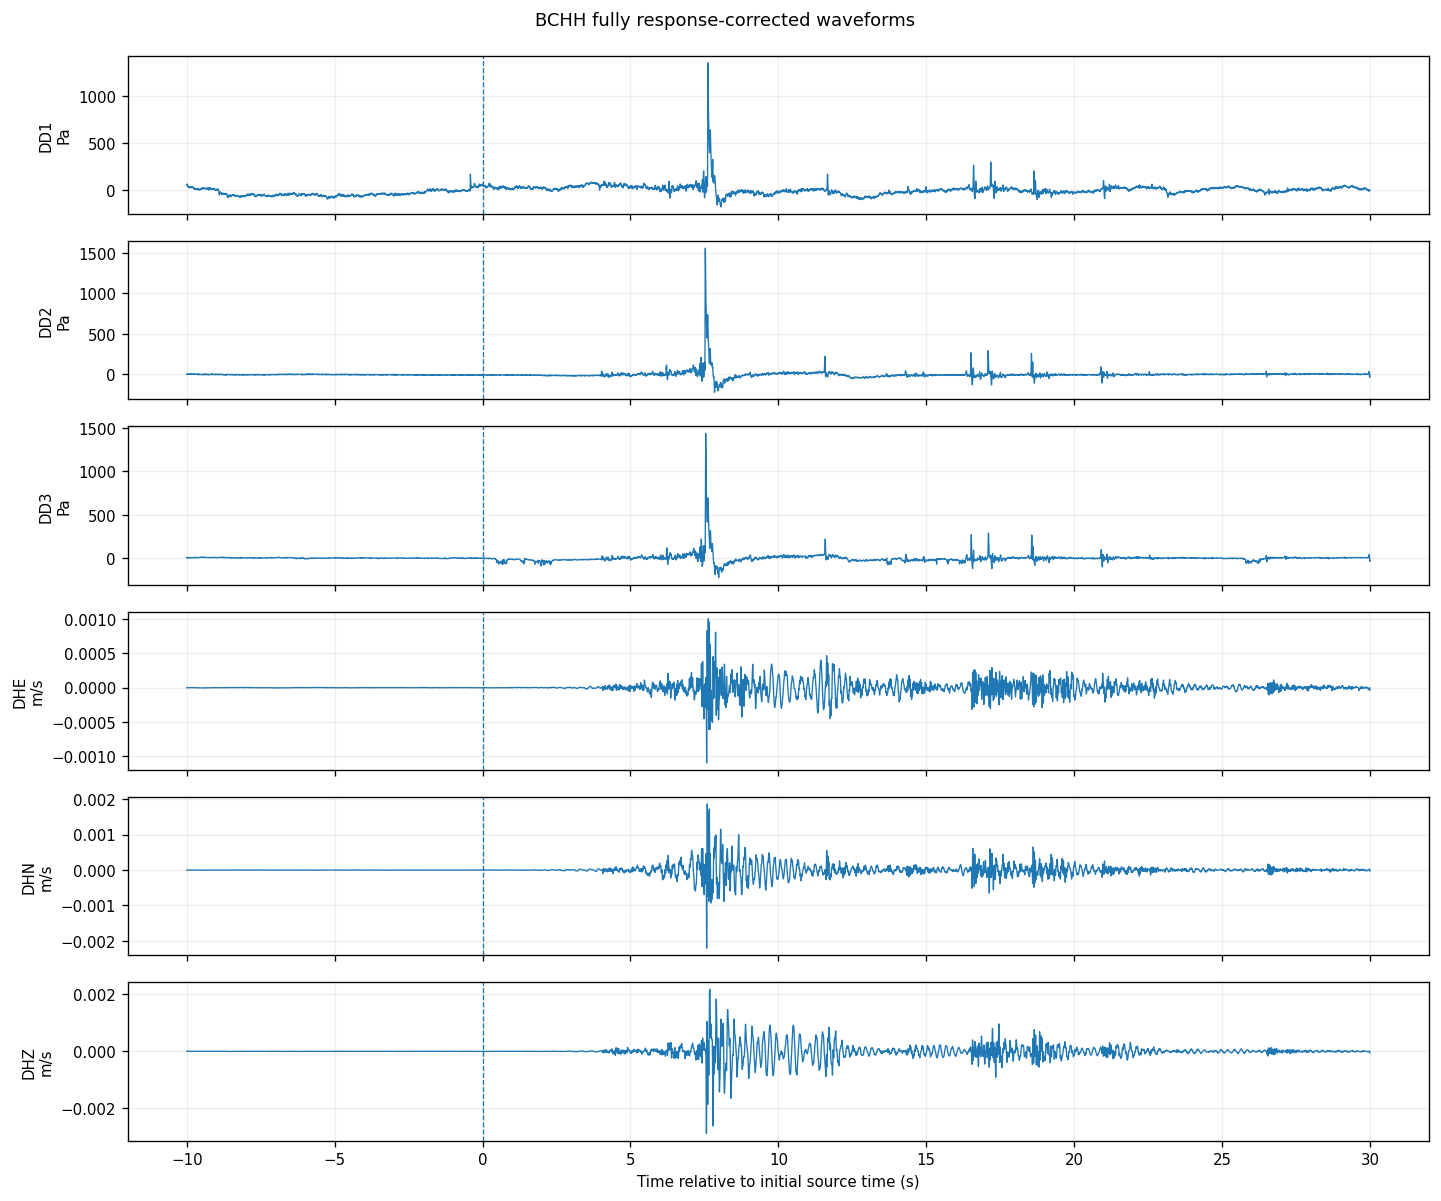

Saved diagnostic figure: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/BCHH_20160901_response_corrected.pdf


In [7]:
PLOT_START = config.EXPLOSION_TIME - 10.0
PLOT_END = config.EXPLOSION_TIME + 30.0

fig, axes = plt.subplots(
    len(CHANNEL_ORDER),
    1,
    figsize=(12, 10),
    sharex=True,
)
for axis, channel_code in zip(axes, CHANNEL_ORDER):
    matches = st_corrected_final.select(
        network=BCHH_NETWORK,
        station=BCHH_STATION,
        location=BCHH_LOCATION,
        channel=channel_code,
    )
    if len(matches) != 1:
        raise ValueError(
            f"Expected one corrected trace for {channel_code}; "
            f"found {len(matches)}"
        )
    trace = matches[0].copy()
    trace.trim(PLOT_START, PLOT_END, pad=False)
    relative_time_s = (
        trace.times()
        + float(trace.stats.starttime - config.EXPLOSION_TIME)
    )
    axis.plot(relative_time_s, trace.data, linewidth=0.8)
    axis.axvline(0.0, linestyle="--", linewidth=0.8)
    axis.set_ylabel(
        f"{channel_code}\n"
        + ("Pa" if channel_code in PRESSURE_CHANNELS else "m/s")
    )
    axis.grid(alpha=0.2)

axes[-1].set_xlabel("Time relative to initial source time (s)")
fig.suptitle("BCHH fully response-corrected waveforms", y=0.995)
fig.tight_layout()
diagnostic_figure = (
    config.NB000_DIR
    / "BCHH_20160901_response_corrected.pdf"
)
fig.savefig(diagnostic_figure, bbox_inches="tight")
plt.show()
print(f"Saved diagnostic figure: {diagnostic_figure}")

## 7. Save processing provenance

In [8]:
processing_metadata = {
    "notebook": (
        "000_correct_bchh_instrument_response.ipynb"
    ),
    "waveform_source": {
        **waveform_source,
        "network": BCHH_NETWORK,
        "station": BCHH_STATION,
        "location": BCHH_LOCATION,
        "channels": list(CHANNEL_ORDER),
    },
    "raw_event_miniseed": str(config.RAW_MSEED),
    "original_stationxml": str(config.STATIONXML_FILE),
    "event_stationxml": str(config.EVENT_STATIONXML_COPY),
    "event_time": str(config.EXPLOSION_TIME),
    "read_start": str(READ_START),
    "read_end": str(READ_END),
    "actual_common_read_start": str(ACTUAL_READ_START),
    "actual_common_read_end": str(ACTUAL_READ_END),
    "raw_boundary_shortfall_tolerance_s": (
        RAW_BOUNDARY_SHORTFALL_TOLERANCE_S
    ),
    "accepted_raw_boundary_shortfalls": (
        accepted_boundary_shortfalls
    ),
    "pressure_baseline_start": str(PRESSURE_BASELINE_START),
    "pressure_baseline_end": str(PRESSURE_BASELINE_END),
    "empirical_calibrations_pa_per_count": {
        key: float(value)
        for key, value
        in EMPIRICAL_CALIBRATIONS_PA_PER_COUNT.items()
    },
    "infrasound_method": (
        "raw-count median baseline removal followed by complete "
        "response removal using empirically rescaled StationXML responses"
    ),
    "seismic_method": (
        "demean, linear detrend, taper, and complete StationXML "
        "response removal to velocity"
    ),
    "infrasound_pre_filt_hz": list(INFRASOUND_PRE_FILT),
    "seismic_pre_filt_hz": list(SEISMIC_PRE_FILT),
    "water_level_db": float(RESPONSE_WATER_LEVEL_DB),
    "authoritative_inventory": str(config.FINAL_INVENTORY_XML),
    "authoritative_corrected_mseed": str(
        config.FINAL_CORRECTED_MSEED
    ),
    "authoritative_corrected_pickle": str(
        config.FINAL_CORRECTED_PICKLE
    ),
    "correction_summary": str(config.FINAL_CORRECTION_SUMMARY),
    "correction_summary_join_key": "seed_id",
    "pickle_trace_metadata_groups": [
        "coordinates",
        "source_geometry",
        "calibration",
        "record_statistics",
        "channel_processing_summary",
    ],
}
config.PROCESSING_JSON.write_text(
    json.dumps(processing_metadata, indent=2),
    encoding="utf-8",
)
print(f"Saved provenance: {config.PROCESSING_JSON}")

Saved provenance: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/bchh_response_processing.json


## 8. Authoritative outputs

Downstream Python workflows should prefer the response-corrected Pickle when
the attached ObsPy metadata are needed. The corrected miniSEED is the
interoperable waveform product; its physical units and processing provenance
are documented by the calibrated StationXML, summary CSV, and processing JSON.

In [9]:
authoritative_outputs = {
    "raw_miniseed": config.RAW_MSEED,
    "original_event_stationxml": config.EVENT_STATIONXML_COPY,
    "calibrated_event_stationxml": config.FINAL_INVENTORY_XML,
    "corrected_miniseed": config.FINAL_CORRECTED_MSEED,
    "corrected_pickle": config.FINAL_CORRECTED_PICKLE,
    "channel_summary": config.FINAL_CORRECTION_SUMMARY,
    "processing_record": config.PROCESSING_JSON,
    "diagnostic_figure": diagnostic_figure,
}
for role, path in authoritative_outputs.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing {role}: {path}")
    print(f"{role}: {path}")

raw_miniseed: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/01_bchh_raw_event_window.mseed
original_event_stationxml: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/bchh_event_inventory_original.xml
calibrated_event_stationxml: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/BCHH_20160901_empirically_calibrated.xml
corrected_miniseed: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correct_bchh_instrument_response/BCHH_20160901_response_corrected.mseed
corrected_pickle: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/000_correc